Import necessary packages

In [26]:
import networkx as nx
import json
from networkx.readwrite import json_graph
from collections import defaultdict
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from community import community_louvain
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import pandas as pd
from wordcloud import WordCloud
import math
import matplotlib.cm as cm
from pathlib import Path
import matplotlib.colors as mcolors
from collections import Counter

Create function to load data in a proper format

In [2]:
def parse_rfa(file_path):
    with open(file_path, 'rt', encoding='utf-8') as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

Create a function that builds the graph

In [3]:
def build_voter_graph(data):
    votes_by_candidate = defaultdict(list)

    for d in data:
        src = d.get("SRC", "").strip()
        tgt = d.get("TGT", "").strip()

        if not src or not tgt:
            continue

        vote = int(d["VOT"])

        # skip neutral votes
        if vote == 0:
            continue

        votes_by_candidate[tgt].append((src, vote))

    G = nx.Graph()

    for cand, voter_list in votes_by_candidate.items():
        for (u, vote_u), (v, vote_v) in combinations(voter_list, 2):

            pair_weight = vote_u * vote_v  # +1 agreement, -1 disagreement

            if G.has_edge(u, v):
                G[u][v]["weight"] += pair_weight
                G[u][v]["count"] += 1
            else:
                G.add_edge(u, v, weight=pair_weight, count=1)
        
    for u, v, data in G.edges(data=True):
        data["normalized"] = round(data["weight"] / data["count"], 5)

    return G

Build the graph and check for amount of nodes and edges

In [4]:
data = parse_rfa("wiki-RfA.txt")
G = build_voter_graph(data)

print("Voter graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print(list(G.edges(data=True))[:10])

Voter graph:
Nodes: 10283
Edges: 3055279
[('Steel1943', 'Cuchullain', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'INeverCry', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Cncmaster', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Miniapolis', {'weight': 0, 'count': 2, 'normalized': 0.0}), ('Steel1943', 'Sven Manguard', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Ramaksoud2000', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'RockMagnetist', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Carrite', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Someguy1221', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Secret', {'weight': 0, 'count': 2, 'normalized': 0.0})]


Saves graph as .json file

In [5]:
proj = json_graph.node_link_data(G)

with open("voter_graph.json", "w") as f:
    json.dump(proj, f)

Amount of edges appears to be far too big. Checking for distribution and percentiles of counts

In [6]:
# distribution of counts
counts = [d["count"] for _, _, d in G.edges(data=True)]

print("Min:", min(counts))
print("Max:", max(counts))
print("Average:", sum(counts)/len(counts))

# percentiles
counts = np.array([d["count"] for _, _, d in G.edges(data=True)])

print("Percentiles:")
for p in [50, 75, 80, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(counts, p))

Min: 1
Max: 672
Average: 3.5340612101218905
Percentiles:
50th percentile: 1.0
75th percentile: 3.0
80th percentile: 4.0
90th percentile: 7.0
95th percentile: 12.0
99th percentile: 35.0


Appears to be a lot of noise among the edges with a small number of co-votes. Decides to create a threshold of 4 minimum co-votes to create an edges to avoid creating a graph that is too big and noisy

Creates 2 filtered graphs: G_agree for co-voters with mostly agreement, and G_disagree for co-voters with mostly disagreement

In [7]:
G_agree = nx.Graph()
G_disagree = nx.Graph()

for u, v, data in G.edges(data=True):
    c = data["count"]
    n = data["normalized"]
    w = data["weight"]

    # Keep only edges with enough evidence
    if c < 4:
        continue

    # Agreement graph
    if n > 0:
        G_agree.add_edge(
            u,
            v,
            count=c,
            weight=w,
            normalized=n,
            community_weight=n
        )

    # Disagreement graph
    elif n < 0:
        G_disagree.add_edge(
            u,
            v,
            count=c,
            weight=abs(w),
            normalized=n,
            community_weight=abs(n)
        )

print("Agree graph:")
print("Nodes:", G_agree.number_of_nodes())
print("Edges:", G_agree.number_of_edges())

print("\nDisagree graph:")
print("Nodes:", G_disagree.number_of_nodes())
print("Edges:", G_disagree.number_of_edges())

Agree graph:
Nodes: 5106
Edges: 498430

Disagree graph:
Nodes: 4317
Edges: 105995


Save agreement graph

In [8]:
agree = json_graph.node_link_data(G_agree)

with open("agree_graph.json", "w", encoding="utf-8") as f:
    json.dump(agree, f)

Save disagreement graph

In [9]:
disagree = json_graph.node_link_data(G_disagree)

with open("disagree_graph.json", "w", encoding="utf-8") as f:
    json.dump(disagree, f)

Basic statistics of agreement graph

In [25]:
def graph_stats(G, name):
    degrees = [d for _, d in G.degree()]
    weights = [d["normalized"] for _, _, d in G.edges(data=True)]
    counts  = [d["count"]      for _, _, d in G.edges(data=True)]
    print(f"--- {name} ---")
    print(f"  Nodes:              {G.number_of_nodes()}")
    print(f"  Edges:              {G.number_of_edges()}")
    print(f"  Avg degree:         {np.mean(degrees):.2f}")
    print(f"  Max degree:         {max(degrees)}")
    print(f"  Avg |norm weight|:  {np.mean(np.abs(weights)):.4f}")
    print(f"  Avg co-vote count:  {np.mean(counts):.2f}")
    print(f"  Max co-vote count:  {max(counts)}")
    print()

graph_stats(G_agree, "Agreement")

--- Agreement ---
  Nodes:              5106
  Edges:              498430
  Avg degree:         195.23
  Max degree:         2691
  Avg |norm weight|:  0.6587
  Avg co-vote count:  12.34
  Max co-vote count:  672



Community detection for agreement graph with a fixed random seed for reproducibility

In [10]:
partition_agree = community_louvain.best_partition(
    G_agree,
    weight="community_weight",
    random_state=42
)

Basic summary

In [11]:
num_communities = len(set(partition_agree.values()))
print("Number of communities:", num_communities)

community_sizes = Counter(partition_agree.values())
print("\nLargest communities:")
for comm, size in community_sizes.most_common(10):
    print(f"Community {comm}: {size} nodes")

Number of communities: 6

Largest communities:
Community 5: 1694 nodes
Community 2: 1318 nodes
Community 3: 1085 nodes
Community 0: 991 nodes
Community 4: 14 nodes
Community 1: 4 nodes


Attach community labels to the graph

In [12]:
nx.set_node_attributes(G_agree, partition_agree, "community")

Save graph with communites

In [13]:
com = json_graph.node_link_data(G_agree)

with open("agree_graph_communities.json", "w", encoding="utf-8") as f:
    json.dump(com, f)

Checking if all voters have been assigned to a community

In [14]:
node_to_community = {
    node: attrs["community"]
    for node, attrs in G_agree.nodes(data=True)
    if "community" in attrs
}

print("Nodes with community labels:", len(node_to_community))

Nodes with community labels: 5106


Checking how many texts there are in total

In [15]:
def parse_rfa(file_path):
    with open(file_path, "rt", encoding="utf-8") as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

records = parse_rfa("wiki-RfA.txt")
print("Records:", len(records))

Records: 198275


Checking for each community

In [16]:
texts_by_community = defaultdict(list)

for r in records:
    src = r.get("SRC")
    txt = r.get("TXT", "").strip()

    if not txt:
        continue

    if src in node_to_community:
        comm = node_to_community[src]
        texts_by_community[comm].append(txt)

for comm, texts in texts_by_community.items():
    print(f"Community {comm}: {len(texts)} texts")

Community 0: 32894 texts
Community 2: 47914 texts
Community 5: 63989 texts
Community 3: 38739 texts
Community 4: 39 texts
Community 1: 10 texts


Appears to be a sufficient amount for the 4 largest communities, but not so much for the 2 small ones. Will keep this in mind when analyzing TF-IDF and Wordclouds

Defines each community to be 1 document

In [17]:
community_ids = sorted(texts_by_community.keys())
community_documents = [
    " ".join(texts_by_community[comm])
    for comm in community_ids
]

print("Number of community documents:", len(community_documents))

Number of community documents: 6


Defines stopwords for filtering

In [18]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreasstampedalgaard/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Defines additional custom stopwords to remove noise

In [19]:
custom_stopwords = {
    "support", "oppose", "neutral",
    "wikipedia", "wiki", "user", "editor",
    "admin", "candidate", "rfa",
    "vote", "voted", "voting",
    "page", "article",
    "would", "could", "should", "also",
    "one", "two", "well", "like", "think",
    "see", "really", "much", "many",
    "per", "however", "since",
    "make", "made",
    "nbsp", "mdash", "ndash", "nom"
}

all_stopwords = stop_words.union(custom_stopwords)

Creates a function to filter text to remove noise, mistakes, errors, links, weird symbols and the likes

In [20]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"\[\[.*?\]\]", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"'{2,}", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    tokens = text.split()
    
    tokens = [
        w for w in tokens
        if w not in all_stopwords and len(w) > 2
    ]
    
    return " ".join(tokens)

Applies function to documents

In [21]:
community_documents = [
    " ".join(clean_text(t) for t in texts_by_community[c])
    for c in community_ids
]

Calculates TF-IDF and saves in DataFrame

In [22]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    max_df=0.9,
    min_df=1,
    ngram_range=(1, 2)        
)

X = vectorizer.fit_transform(community_documents)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X.toarray(),
    index=[f"community_{c}" for c in community_ids],
    columns=terms
)

Finds top TF-IDF words for each community

In [23]:
for comm in community_ids:
    row = tfidf_df.loc[f"community_{comm}"]
    top_terms = row.sort_values(ascending=False).head(20)

    print(f"\nTop TF-IDF terms for community {comm}:")
    for term, score in top_terms.items():
        print(f"{term}: {score:.4f}")


Top TF-IDF terms for community 0:
work: 0.2773
tools: 0.2274
experience: 0.2261
time: 0.1698
concerns: 0.1663
edits: 0.1647
content: 0.1463
contributions: 0.1398
enough: 0.1370
answers: 0.1340
seems: 0.1260
great: 0.1241
questions: 0.1128
areas: 0.1124
months: 0.1021
seen: 0.1016
answer: 0.1011
reason: 0.1009
need: 0.0999
project: 0.0983

Top TF-IDF terms for community 1:
ghirlandajo: 0.2350
alex: 0.2174
rights: 0.1305
contributors: 0.1305
alex bakharev: 0.1007
bakharev: 0.1007
disputes: 0.0870
willing: 0.0870
russian: 0.0870
trolls: 0.0870
insulted: 0.0870
wars wishing: 0.0849
giving ghirlandajo: 0.0849
anonymous trolls: 0.0849
wanting posess: 0.0849
alex nice: 0.0849
users insulted: 0.0849
users contributors: 0.0849
unwilling provoke: 0.0849
alex division: 0.0849

Top TF-IDF terms for community 2:
tools: 0.2916
work: 0.2388
experience: 0.2348
edits: 0.1903
time: 0.1637
great: 0.1395
enough: 0.1357
concerns: 0.1241
contributions: 0.1229
seems: 0.1200
answers: 0.1191
project: 0.1114
n

Creates wordclouds for each community

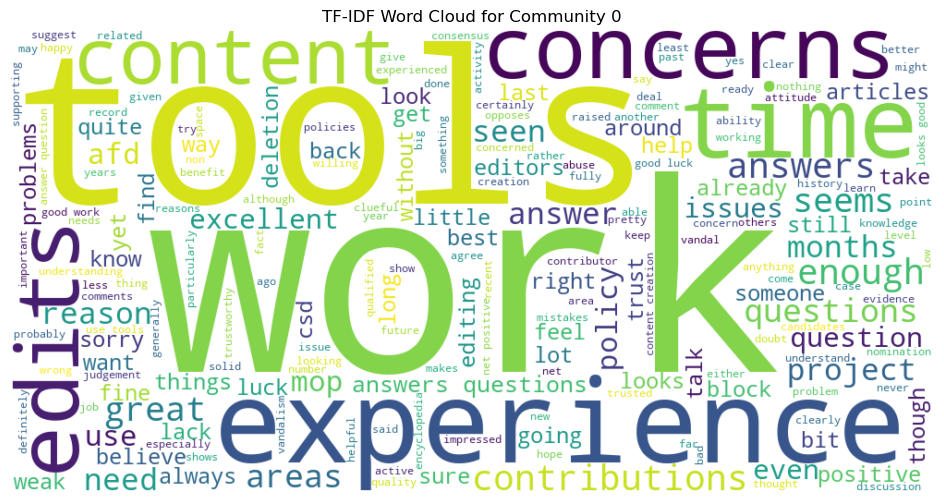

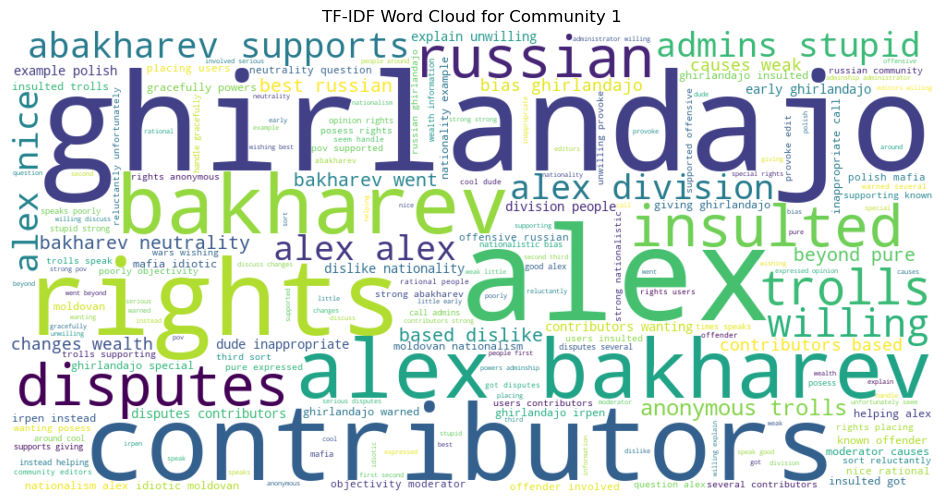

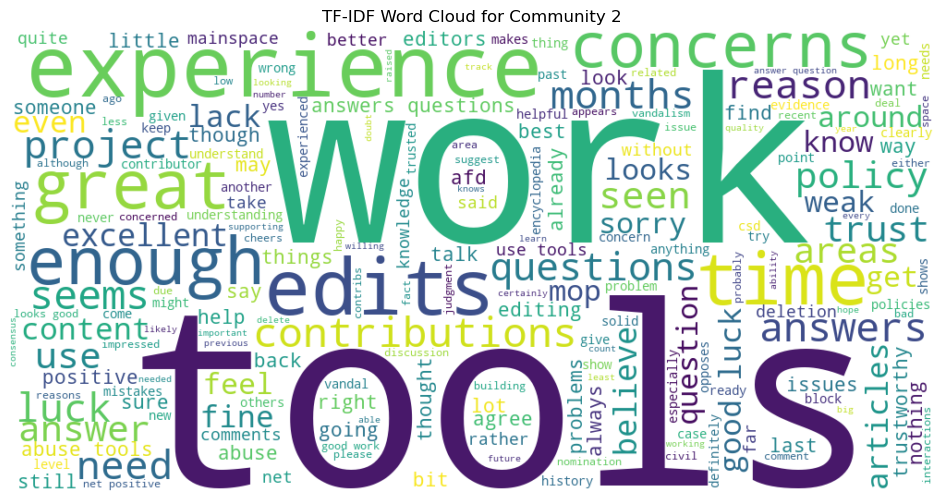

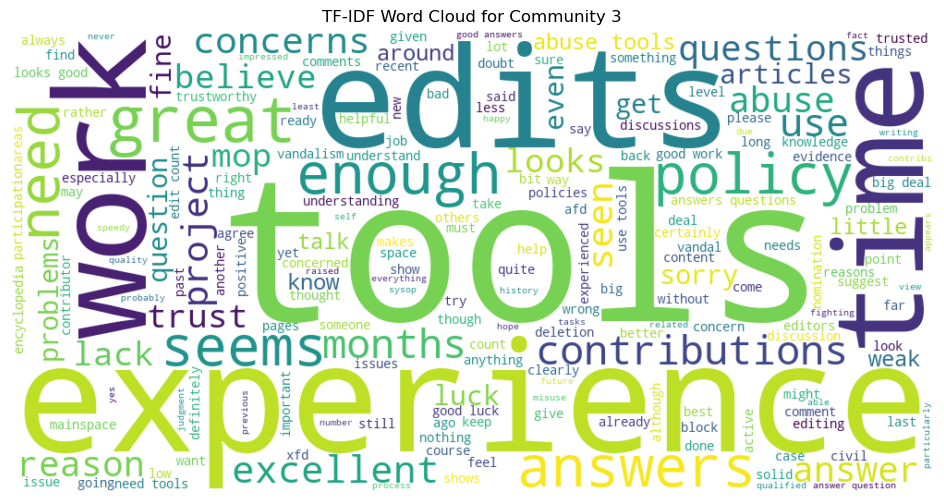

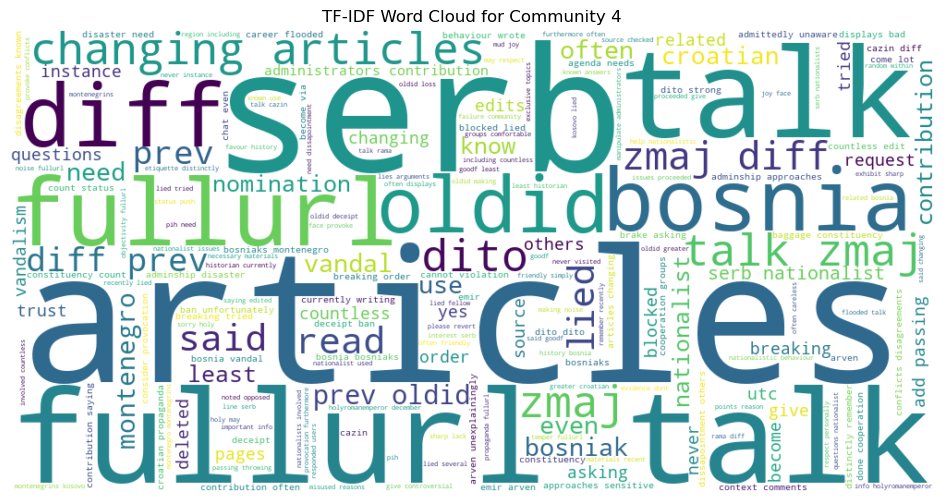

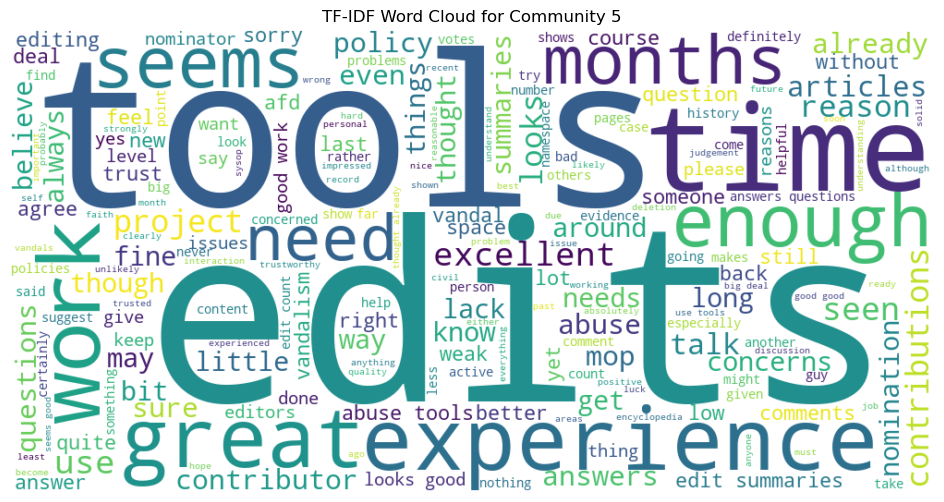

In [24]:
for c in community_ids:
    row = tfidf_df.loc[f"community_{c}"]
    
    freq_dict = row[row > 0].to_dict()

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud for Community {c}")
    plt.show()

Top 4 communites seems to share their top TF-IDF words, which all seem realistic. The 2 small communites appear to have very wwierd and random words, which is most likely due to their small size and limited amount of texts. Considers only focusing on top 4 communities from here

Community summary

/var/folders/sl/435gx6y958q0v8qp_2lgbcww0000gn/T/ipykernel_49412/2401226340.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(community_ids))


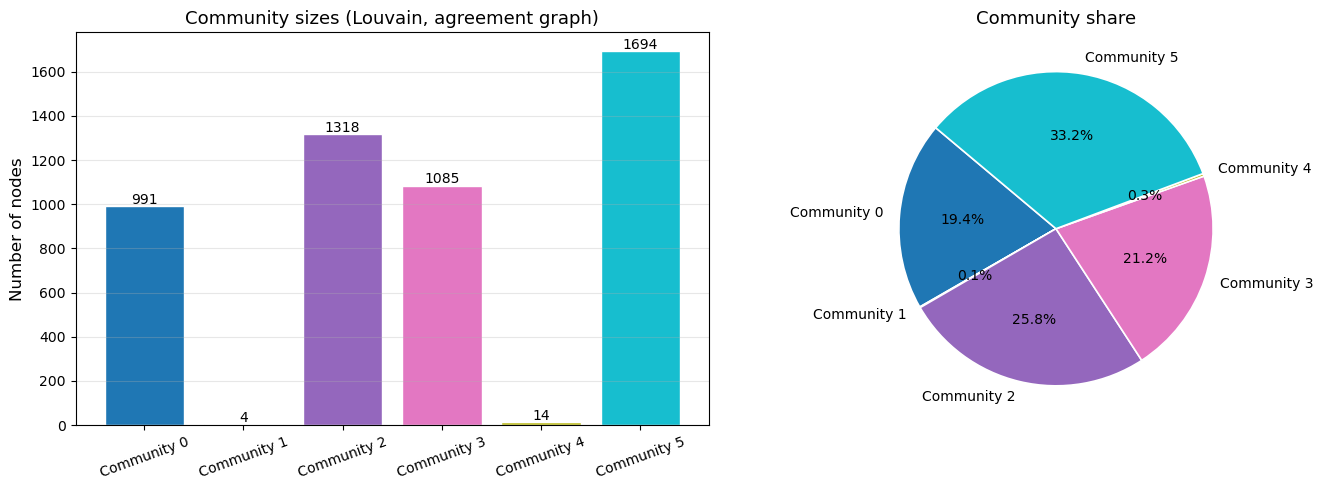


Average normalized weight within each community:
  Community 0: 0.6894 (over 67847 intra-community edges)
  Community 1: 1.0000 (over 6 intra-community edges)
  Community 2: 0.6424 (over 86348 intra-community edges)
  Community 3: 0.6852 (over 43275 intra-community edges)
  Community 4: 1.0000 (over 80 intra-community edges)
  Community 5: 0.7048 (over 117775 intra-community edges)


In [27]:
# Pull community labels from node attributes
partition = nx.get_node_attributes(G_agree, "community")
community_ids = sorted(set(partition.values()))

# Map community IDs to colours (tab10 palette)
cmap = cm.get_cmap("tab10", len(community_ids))
COMM_COLORS = {c: mcolors.to_hex(cmap(i)) for i, c in enumerate(community_ids)}

# Sizes
sizes = Counter(partition.values())
labels = [f"Community {c}" for c in community_ids]
values = [sizes[c] for c in community_ids]
colors = [COMM_COLORS[c] for c in community_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(labels, values, color=colors, edgecolor="white")
axes[0].set_ylabel("Number of nodes", fontsize=12)
axes[0].set_title("Community sizes (Louvain, agreement graph)", fontsize=13)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=10)

# Pie chart
axes[1].pie(
    values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
axes[1].set_title("Community share", fontsize=13)

plt.tight_layout()
plt.savefig("community_summary.png", dpi=150)
plt.show()

# Per-community avg strength
print("\nAverage normalized weight within each community:")
for c in community_ids:
    members = {n for n, comm in partition.items() if comm == c}
    intra = [
        d["normalized"]
        for u, v, d in G_agree.edges(data=True)
        if u in members and v in members
    ]
    if intra:
        print(f"  Community {c}: {np.mean(intra):.4f} (over {len(intra)} intra-community edges)")

Temporal analysis

In [29]:
# Load original directed voting graph for year data
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    G_orig = json_graph.node_link_graph(json.load(f))

print(f"Original graph: {G_orig.number_of_nodes()} nodes, {G_orig.number_of_edges()} edges")

# Build a flat record list from edges
records = []
for u, v, d in G_orig.edges(data=True):
    records.append({
        "voter":     u,
        "candidate": v,
        "vote":      d.get("vote", 0),
        "result":    d.get("result", 0),
        "year":      d.get("year"),
        "voter_community":     partition.get(u),
        "candidate_community": partition.get(v),
    })

df = pd.DataFrame(records)
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

print(f"Years in dataset: {df['year'].min()} – {df['year'].max()}")
print(df.head())

Original graph: 11381 nodes, 198275 edges
Years in dataset: 2003 – 2013
       voter      candidate  vote  result  year  voter_community  \
0  Steel1943            BDD     1       1  2013              NaN   
1  Steel1943  RockMagnetist     0       1  2013              NaN   
2  Steel1943        Shirt58     0       1  2013              NaN   
3  Steel1943    Jasper Deng    -1      -1  2013              NaN   
4        BDD     Miniapolis     1       1  2013              0.0   

   candidate_community  
0                  0.0  
1                  0.0  
2                  NaN  
3                  0.0  
4                  0.0  


When each community was active

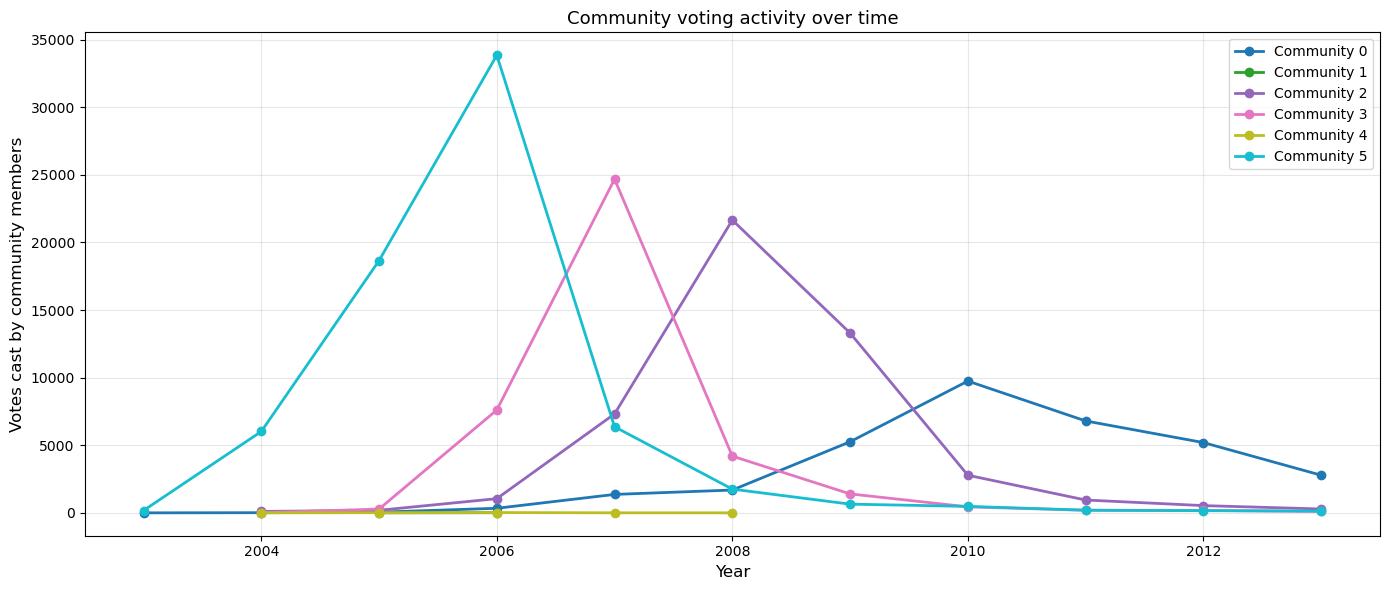

Peak activity year per community:
  Community 0: 2010 (9746 votes)
  Community 1: 2006 (9 votes)
  Community 2: 2008 (21651 votes)
  Community 3: 2007 (24677 votes)
  Community 4: 2006 (22 votes)
  Community 5: 2006 (33842 votes)


In [30]:
# Only keep votes where the voter belongs to a known community
df_comm = df[df["voter_community"].notna()].copy()
df_comm["voter_community"] = df_comm["voter_community"].astype(int)

# Count votes cast per community per year
comm_year = (
    df_comm.groupby(["year", "voter_community"])
    .size()
    .reset_index(name="votes")
)

fig, ax = plt.subplots(figsize=(14, 6))

for comm in sorted(df_comm["voter_community"].unique()):
    subset = comm_year[comm_year["voter_community"] == comm]
    ax.plot(
        subset["year"], subset["votes"],
        marker="o", linewidth=2, label=f"Community {comm}",
        color=COMM_COLORS.get(comm, "#aaaaaa")
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Votes cast by community members", fontsize=12)
ax.set_title("Community voting activity over time", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("temporal_community_activity.png", dpi=150)
plt.show()

# Also print peak year per community
print("Peak activity year per community:")
for comm in sorted(df_comm["voter_community"].unique()):
    subset = comm_year[comm_year["voter_community"] == comm]
    peak = subset.loc[subset["votes"].idxmax()]
    print(f"  Community {comm}: {int(peak['year'])} ({int(peak['votes'])} votes)")

Appears that communities might have been created based on activity period